# Assignment 1 — Environment & First Network

**DATAX504** · Due end of Week 2 · **NumPy only** (no Keras/TensorFlow for the network)

## Tasks
1. Document OpenCode setup (screenshot or log in `opencode_setup/` folder)
2. Train a 2-layer dense network on synthetic data below
3. Plot training loss over 100 epochs
4. Write a ~200-word reflection on OpenCode use

## Moodle fields
`a1_repo`, `a1_loss_final`, `a1_params`, `a1_opencode_model`, `a1_reflection`

## AI disclosure

| Field | Your answer                                                                                                                                                                                                                                                                               |
|-------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Tool | e.g. OpenCode Zen + Big Pickle                                                                                                                                                                                                                                                            |
| Used for | Code debugging, runtime error analysis, code review, checking matrix dimensions and NumPy broadcasting, and identifying potential issues in forward/backward propagation.                                                                                                                 |
| Verified how | All suggestions were manually reviewed before acceptance. The program was re-run after each change, and correctness was verified by successful execution, decreasing training loss, improving classification accuracy, and comparing the implementation with the assignment requirements. |
| Not used for | Generating the complete neural network implementation, writing the core algorithms from scratch, or producing the final solution without manual development.                                                                                                                              |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(504) #fixed the seed to make results reproducible
plt.rcParams["figure.figsize"] = (8, 4) #set the default figure(canvas) size

## 1. Synthetic dataset

Two moons–style binary classification in 2D (non-linear boundary).

X shape: (1000, 2) y shape: (1000, 1)


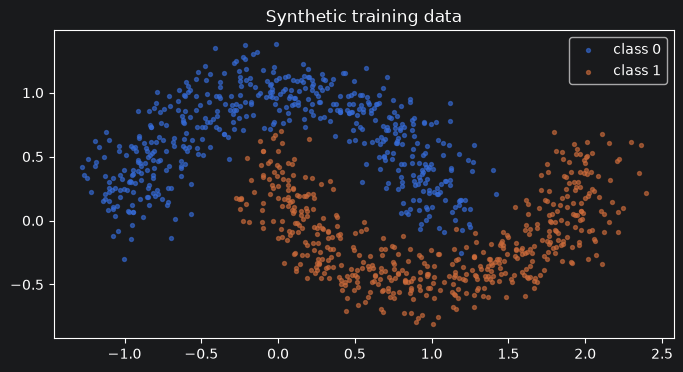

In [2]:
def make_moons(n_samples=1000, noise=0.15):
    """Simple two-moons dataset. Returns X (n, 2), y (n, 1)."""
    n = n_samples // 2 #half of the samples
    theta = np.linspace(0, np.pi, n) #generate n angles from 0-pi
    moon1 = np.c_[np.cos(theta), np.sin(theta)] #combination to two dimensions array, it's coordinate
    moon2 = np.c_[1 - np.cos(theta), 1 - np.sin(theta) - 0.5] #inverse
    X = np.vstack([moon1, moon2]) #stack vertically the two arrays, original shape(1000,2)
    X += np.random.randn(*X.shape) * noise #生成与 X 形状相同的随机数数组，这些随机数服从标准正态分布（均值为 0，标准差为 1）。*X.shape：解包 X 的形状，作为 randn 函数的参数，生成与 X 相同维度的随机数组.X += ...：将生成的带有噪声的随机数数组加到 X 上，相当于为 X 中的每个元素增加一个随机扰动。
    y = np.vstack([np.zeros((n, 1)), np.ones((n, 1))]) #np.zeros((n, 1))：生成一个大小为 $ n \times 1 $ 的二维数组，数组中的所有元素值为 0。通常用于表示第一类样本的标签。np.ones((n, 1))：生成一个大小为 $ n \times 1 $ 的二维数组，数组中的所有元素值为 1。通常用于表示第二类样本的标签。np.vstack([np.zeros(...), np.ones(...)])：将这两个数组按行垂直堆叠，生成一个总共有 $ 2n \times 1 $ 的标签数组 y。最终，y 的前 n 行为 0（表示一类），后 n 行为 1（表示另一类），常用于监督学习任务中的分类标签。
    return X.astype(np.float32), y.astype(np.float32) #convert to float32 to reduce the memory usage

X, y = make_moons(1000)
print("X shape:", X.shape, "y shape:", y.shape)

plt.scatter(X[y.ravel() == 0, 0], X[y.ravel() == 0, 1], s=8, alpha=0.6, label="class 0") #y.ravel() == 0：将标签数组 y 展平为一维数组（0），并筛选出值为 0 的索引（即类别为 0 的样本）。s=8：设置点的大小为 8。alpha=0.6：设置点的透明度为 0.6，避免点过于密集时重叠严重。label="class 0"：为这些点设置标签，用于后续图例显示。
plt.scatter(X[y.ravel() == 1, 0], X[y.ravel() == 1, 1], s=8, alpha=0.6, label="class 1")
plt.legend() #显示图例
plt.title("Synthetic training data")
plt.show()

## 2. Activation functions

In [3]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x): # for back propagation, True-1, False-0
    return (x > 0).astype(np.float32) #(x > 0) 实际上是对整个数组 x 的每个元素进行判断，返回一个与 x 形状相同的布尔数组。最终结果等价于 ReLU 的导数：输入大于 0 的地方导数为 1，小于等于 0 的地方导数为 0。

def sigmoid(x): #output is between 0-1
    return 1 / (1 + np.exp(-np.clip(x, -500, 500))) #np.clip(x, -500, 500)，将 x 中的值限制在区间 [-500, 500] 内。如果某个值小于 -500，就设为 -500；如果大于 500，就设为 500。这是为了防止 np.exp(-x) 计算时出现数值溢出（overflow）问题，尤其是在 x 很小时，exp(x) 会变得极大。np.exp(-np.clip(x, -500, 500))：计算 e 的负 x 次方，其中 x 是被裁剪过的值。

# TODO: implement sigmoid_derivative if you need it for backprop
def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x)) #这个函数返回的是一个与 x 形状相同的数组，每个元素是对应位置的导数值。

## 3. Network parameters

Architecture: **2 inputs → 16 hidden (ReLU) → 1 output (sigmoid)**

Use He initialisation for `W1` and a small scale for `W2`.

In [4]:
input_size, hidden_size, output_size = 2, 16, 1
learning_rate = 0.1
epochs = 100

# TODO: initialise W1, b1, W2, b2
W1 = np.random.randn(input_size, hidden_size).astype(np.float32) * np.sqrt(2 / input_size) #生成服从标准正态分布（均值为 0，标准差为 1）的随机数，使用 He 初始化（He initialization）方法对权重进行缩放，有助于缓解梯度消失/爆炸问题。这行代码会生成一个形状为 (input_size, hidden_size) 的二维数组。数组中包含的随机数个数为：input_size * hidden_size
b1 = np.zeros((1, hidden_size), dtype=np.float32) #创建一个形状为 (1, hidden_size) 的全 0 数组，表示偏置。
W2 = np.random.randn(hidden_size, output_size).astype(np.float32) * 0.01 #生成服从标准正态分布的随机数。* 0.01：对权重进行小幅度缩放，防止初始值过大导致梯度不稳定。
b2 = np.zeros((1, output_size), dtype=np.float32)

total_params = W1.size + b1.size + W2.size + b2.size #W1(2, 16)：2 * 16 = 32；b1：(1, 16) 16；W2(16, 1)：16 * 1 = 16；b2：(1, 1) 1
print(f"Total trainable parameters: {total_params}")

Total trainable parameters: 65


## 4. Forward & backward pass

Implement one training step. Hint: binary cross-entropy loss gradient at sigmoid output simplifies to `(A2 - y) / m`.

In [5]:
def forward(X, W1, b1, W2, b2):
    """Return cache dict with intermediates for backprop."""
    Z1 = X @ W1 + b1 #Z: logit/linear output
    A1 = relu(Z1) #A: activation
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)
    return {"Z1": Z1, "A1": A1, "A2": A2}

def backward(X, y, cache, W2):
    """Return gradients dW1, db1, dW2, db2."""
    m = X.shape[0] #样本数量
    A1, A2 = cache["A1"], cache["A2"] #隐藏层的激活值、输出层的激活值（m, n_h)/ (m,n_y)
    # TODO: complete backpropagation
    dZ2 = (A2 - y) / m #dZ2: 输出层的误差项，形状为 (m, n_y)。这里使用了简单的均方误差损失函数的导数，即 A2 - y。
    dW2 = A1.T @ dZ2 #dW2: 第二层权重的梯度，形状为 (n_h, n_y)。通过 A1.T @ dZ2 计算得到。
    db2 = np.sum(dZ2, axis=0, keepdims=True) #db2: 第二层偏置的梯度，形状为 (1, n_y)。通过对 dZ2 按行求和得到。
    dA1 = dZ2 @ W2.T #dA1: 隐藏层的误差项，形状为 (m, n_h)。通过 dZ2 @ W2.T 计算得到。
    dZ1 = dA1 * relu_derivative(cache["Z1"]) #dZ1: 隐藏层的误差项，考虑了激活函数的导数（这里是 ReLU 函数的导数），形状为 (m, n_h)。
    dW1 = X.T @ dZ1 #dW1: 第一层权重的梯度，形状为 (n_x, n_h)。通过 X.T @ dZ1 计算得到
    db1 = np.sum(dZ1, axis=0, keepdims=True) #db1: 第一层偏置的梯度，形状为 (1, n_h)。通过对 dZ1 按行求和得到
    return dW1, db1, dW2, db2

def compute_loss(y, A2): #y: 真实标签，形状为 (m, n_y)，其中 m 是样本数量，n_y 是输出层的神经元数量（通常为1，因为是二分类问题）A2: 模型的预测输出，即经过激活函数（通常是Sigmoid函数）后的输出，形状为 (m, n_y)。
    eps = 1e-8 #eps: 一个非常小的值（1e-8），用于防止在对数运算中出现数值不稳定的情况（如 log(0) 会导致无穷大）。
    return -np.mean(y * np.log(A2 + eps) + (1 - y) * np.log(1 - A2 + eps)) #A2 + eps: 在预测值 A2 上加上一个极小值 eps，以确保在计算 log(A2) 时不会出现 log(0) 的情况；y * np.log(A2 + eps): 计算真实标签为1时的损失部分；(1 - y) * np.log(1 - A2 + eps): 计算真实标签为0时的损失部分；返回一个标量值，表示当前模型的平均损失。

## 5. Training loop

In [6]:
loss_history = []

for epoch in range(epochs):
    cache = forward(X, W1, b1, W2, b2) #cache 是一个字典，保存了前向传播过程中的中间值（如激活值 A1, A2 和线性变换的输出 Z1, Z2）。
    loss = compute_loss(y, cache["A2"]) #y 是真实标签，cache["A2"] 是模型的预测输出
    loss_history.append(loss)
    dW1, db1, dW2, db2 = backward(X, y, cache, W2) #调用 backward 函数进行反向传播，计算损失函数对模型参数的梯度
    W1 -= learning_rate * dW1 #使用梯度下降法更新模型参数。learning_rate 是学习率，控制每次参数更新的步长。
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}  loss = {loss:.4f}") #每隔 20 个周期，打印当前周期的损失值。

final_loss = loss_history[-1]
print(f"\nFinal loss (Moodle a1_loss_final): {final_loss:.4f}")

Epoch   0  loss = 0.6900
Epoch  20  loss = 0.4705
Epoch  40  loss = 0.3826
Epoch  60  loss = 0.3383
Epoch  80  loss = 0.3126

Final loss (Moodle a1_loss_final): 0.2969


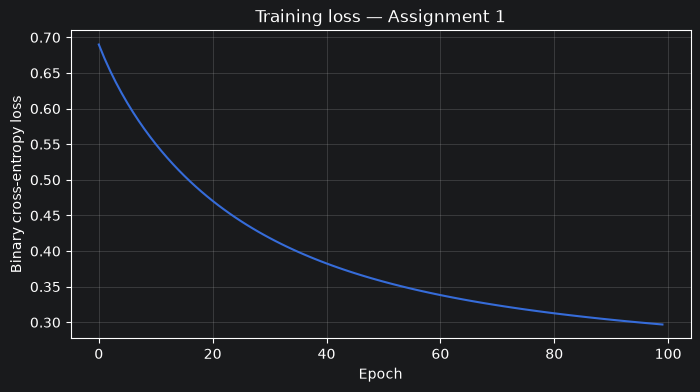

In [7]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Training loss — Assignment 1")
plt.grid(True, alpha=0.3)
plt.show()

## 6. Reflection (Moodle `a1_reflection`)

Write ~200 words:
- One thing OpenCode helped with
- One thing it got wrong or you had to fix
- How you verified the final notebook

*Your reflection here (or paste into Moodle form).*